In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [19]:

def load_data():
    data = pd.read_csv("E:/7th semester/Deep Learning/labs/DL-Assigment/data/ADANIPORTS.csv")
    data.head()
    return data

data.head(100)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.00,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.00,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.00,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.00,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.00,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2008-04-16,MUNDRAPORT,EQ,642.55,657.00,662.00,632.00,641.0,637.40,648.05,440549,2.854984e+13,NaN,141662,0.3216
96,2008-04-17,MUNDRAPORT,EQ,637.40,648.80,659.40,621.05,627.9,626.35,642.94,442496,2.844994e+13,NaN,166569,0.3764
97,2008-04-21,MUNDRAPORT,EQ,626.35,640.00,654.95,633.10,646.0,645.15,644.67,257175,1.657938e+13,NaN,67098,0.2609
98,2008-04-22,MUNDRAPORT,EQ,645.15,640.00,673.40,638.15,671.9,665.85,661.65,574697,3.802497e+13,NaN,174611,0.3038


In [3]:
data.shape

(3322, 15)

In [15]:
data.isnull().sum()


Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                866
Deliverable Volume      0
%Deliverble             0
dtype: int64

In [5]:
# # Drop missing values
# data = data.dropna()
# data

In [14]:
## to describe the dataset
data.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3.322000e+03,3.322000e+03,2.456000e+03,3.322000e+03,3322.000000
mean,344.114314,344.763019,351.608007,337.531969,344.239539,344.201626,344.853182,2.954564e+06,1.070144e+14,4.492259e+04,1.207441e+06,0.445899
std,192.936882,193.619992,198.617808,188.676614,193.187813,193.045886,193.841305,4.104227e+06,2.625564e+14,5.023124e+04,1.398640e+06,0.160496
min,108.000000,108.000000,110.450000,105.650000,108.000000,108.000000,108.340000,1.236600e+04,2.415857e+11,3.660000e+02,5.383000e+03,0.067000
25%,164.312500,164.850000,168.000000,161.600000,164.075000,164.312500,164.855000,7.493682e+05,1.817650e+13,2.083200e+04,3.212005e+05,0.332900
50%,324.700000,325.750000,331.275000,319.850000,325.000000,324.700000,325.765000,2.007292e+06,5.836041e+13,3.588150e+04,8.132775e+05,0.445650
75%,400.912500,401.000000,407.187500,395.000000,400.912500,400.912500,400.607500,3.636883e+06,1.158526e+14,5.336875e+04,1.605528e+06,0.555850
max,1307.450000,1310.250000,1324.000000,1270.000000,1308.000000,1307.450000,1302.150000,9.771788e+07,8.160988e+15,1.205984e+06,2.241652e+07,0.979800


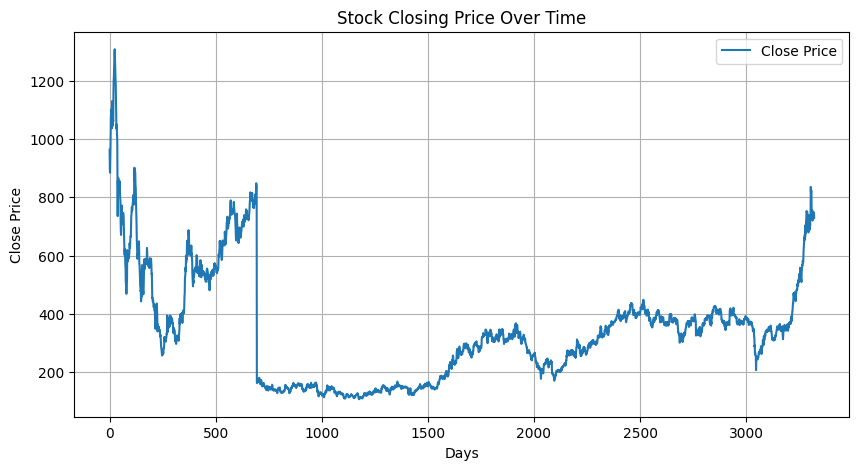

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


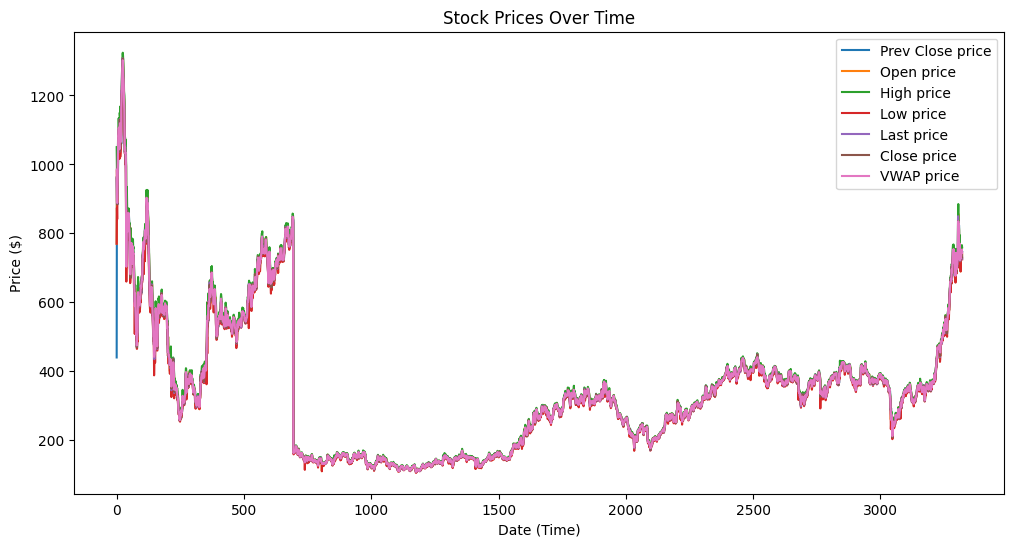

In [ ]:
## Visualize the prev price,open price, close price,prev close price , high price, last price and law price belongs to the  company

prev_close = data['Prev Close']
open_price = data['Open']
high_price = data['High']
low_price = data['Low']
last_price = data['Last']
close_price = data['Close']
vwap_price = data['VWAP']

plt.figure(figsize=(12,6))

plt.plot(prev_close,label='Prev Close price')
plt.plot(open_price,label='Open price')
plt.plot(high_price,label='High price')
plt.plot(low_price,label='Low price')
plt.plot(last_price,label='Last price')
plt.plot(close_price,label='Close price')
plt.plot(vwap_price,label='VWAP price')

plt.legend()
plt.xlabel("Date (Time)")
plt.ylabel("Price ($)")
plt.title("Stock Prices Over Time")
plt.show()


In [16]:
## conclusion - after ploting prev price,open price, close price,prev close price , high price, last price and law price columns those 
# are approximately same variation. then can be consider only one column without getting all these columns for the prediction

In [17]:
## finally can be select to predict the close price of the dataset